In [2]:
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# this will import all the programs I need to read through data and organize, make graphs, and use sql library

In [3]:
base = pd.read_csv("Baseball_Data.csv")
# this will import the data I need

In [4]:
base = base.drop(275)
# this will drop the totals row

In [5]:
base = base.dropna()
# This will drop the null values

In [6]:
print(base)
# this will print the data frame

        Rk                     Name  Yrs  From    To  ASG  WAR  W   L   W-L%  \
2      3.0            Julian Aguiar    1  2024  2024    0 -0.1  2   1  0.667   
3      4.0            Sam Aldegheri    1  2024  2024    0 -0.3  1   2  0.333   
4      5.0          Clayton Andrews    2  2023  2024    0 -0.9  0   1  0.000   
5      6.0       Spencer Arrighetti    1  2024  2024    0  0.3  7  13  0.350   
6      7.0               Nick Avila    1  2024  2024    0 -0.3  1   0  1.000   
..     ...                      ...  ...   ...   ...  ...  ... ..  ..    ...   
264  265.0              Keaton Winn    2  2023  2024    0 -0.8  4  11  0.267   
267  268.0  Simeon Woods Richardson    3  2022  2024    0  1.8  5   6  0.455   
268  269.0         Justin Wrobleski    1  2024  2024    0 -0.4  1   2  0.333   
270  271.0       Yoshinobu Yamamoto    1  2024  2024    0  1.7  7   2  0.778   
271  272.0              Danny Young    3  2022  2024    0  0.2  4   1  0.800   

     ...  IBB   SO  HBP  BK  WP   BF   

In [7]:
base.nunique()
# this will show me how many possible values will be in each column

Rk       178
Name     178
Yrs        5
From       6
To         1
ASG        2
WAR       39
W         15
L         13
W-L%      33
ERA      158
G         54
GS        31
GF        24
CG         2
SHO        2
SV         7
IP       130
H         86
R         63
ER        59
HR        25
BB        51
IBB        7
SO        90
HBP       13
BK         4
WP        10
BF       155
WHIP     155
Debut    141
Age       13
Tm        31
dtype: int64

In [2]:
base.describe()
# this will caculate and print the count, mean, std, min, max, and the quartiles for each column of data

NameError: name 'base' is not defined

In [9]:
base.info()
# this will show me the type of data in each column

<class 'pandas.core.frame.DataFrame'>
Index: 178 entries, 2 to 271
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      178 non-null    float64
 1   Name    178 non-null    object 
 2   Yrs     178 non-null    int64  
 3   From    178 non-null    int64  
 4   To      178 non-null    int64  
 5   ASG     178 non-null    int64  
 6   WAR     178 non-null    float64
 7   W       178 non-null    int64  
 8   L       178 non-null    int64  
 9   W-L%    178 non-null    float64
 10  ERA     178 non-null    float64
 11  G       178 non-null    int64  
 12  GS      178 non-null    int64  
 13  GF      178 non-null    int64  
 14  CG      178 non-null    int64  
 15  SHO     178 non-null    int64  
 16  SV      178 non-null    int64  
 17  IP      178 non-null    float64
 18  H       178 non-null    int64  
 19  R       178 non-null    int64  
 20  ER      178 non-null    int64  
 21  HR      178 non-null    int64  
 22  BB     

In [10]:
base["Tm"].unique()
# this will show me all the possible values for this column

array(['CIN', 'LAA', 'NYY', 'HOU', 'SFG', 'MIA', 'OAK', 'TBR', 'CHW',
       'TOT', 'MIN', 'BOS', 'KCR', 'CHC', 'PIT', 'NYM', 'CLE', 'LAD',
       'ARI', 'COL', 'SEA', 'ATL', 'STL', 'TEX', 'MIL', 'DET', 'WSN',
       'PHI', 'SDP', 'TOR', 'BAL'], dtype=object)

In [11]:
Age = base["Age"]
SO = base["SO"]
HBP = base["HBP"]
WP = base["WP"]
Team = base["Tm"]
win_percentage = base["W-L%"]
whip = base["WHIP"]
bf = base["BF"]
walks = base["BB"]
# these lines of code takes out the columns of data that I want to use for all the questions

In [3]:
sns.violinplot(data=base, x=Age, y=SO)
# I got this line of code from https://seaborn.pydata.org/generated/seaborn.violinplot.html
# this will calcualte and print a violin plot with age of the x-axis and strikeouts on the y-axis

NameError: name 'sns' is not defined

In [4]:
sns.violinplot(data=base, x=Age, y=walks)
# I got this line of code from https://seaborn.pydata.org/generated/seaborn.violinplot.html
# this will calcualte and print a violin plot with age of the x-axis and walks on the y-axis

NameError: name 'sns' is not defined

In [5]:
corr = base['BB'].corr(base['SO'], method='spearman')
print(f"Spearman correlation: {corr}")
# I got this code from https://www.statology.org/spearman-correlation-python/
# this will caculate a spearman correlation score and it is read the same as a pearson one

NameError: name 'base' is not defined

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
# these lines of code with import the programs I need to find KNN, perform the train test split, calculate an accuracy score, and print 
# a confusion matrix

97.22222222222221


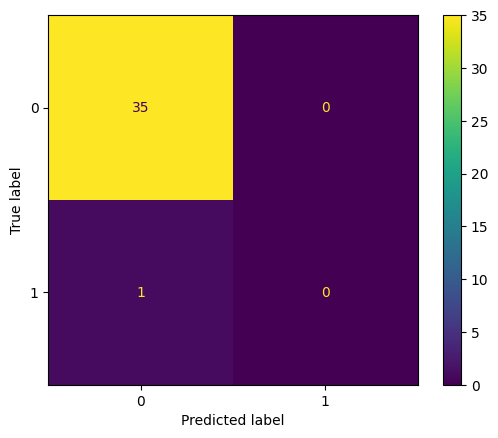

In [31]:
X = base[["WAR", "ERA","WHIP"]]
y = base["ASG"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

classifier = KNeighborsClassifier(n_neighbors=3)

classifier.fit(X_train, y_train)

predictions = classifier.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(accuracy*100)
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)
# These lines of code will create a trained algorithm, idetify what the x and y component are, run a train split test, idetify the classifer
# and the number of neighbors, fit the classifier, set it to make predictions, print and calculate an accuracy score, and print a confusion 
# matrix to show the results it predicted

In [32]:
# what I can tell from this accuracy score and confusion matrix is that the training algorithm went well
# I got an accuracy score of about 97% which means that the training worked almost perfectly
# From the confusion matrix I can tell that it only got incorrect the 2 players that were all stars, when looking at the data it predicted 
# that there would be no all stars

In [34]:
base_data_corr = base.corr(numeric_only=True)
base_data_corr
# these lines of code will calculate and print a correclation table for the data set to show by number what columns correlate best with others

,Rk,Yrs,From,To,ASG,WAR,W,L,W-L%,ERA,...,HR,BB,IBB,SO,HBP,BK,WP,BF,WHIP,Age
Rk,1.000000,-0.008101,0.025066,NaN,0.051769,-0.027952,0.033352,-0.007005,0.008941,0.043041,...,0.039581,0.022491,-0.080135,0.048784,0.034517,0.105291,0.117066,0.072733,-0.052863,-0.037358
Yrs,-0.008101,1.000000,-0.917413,NaN,-0.038183,-0.009782,0.126113,0.098196,-0.004592,0.026717,...,0.147518,0.302310,0.140271,0.141055,0.312549,-0.006944,0.288247,0.194129,0.107521,0.335222
From,0.025066,-0.917413,1.000000,NaN,0.043744,-0.018045,-0.112295,-0.097231,0.015046,-0.000300,...,-0.124211,-0.278903,-0.179770,-0.111862,-0.264157,-0.018778,-0.241872,-0.159394,-0.077044,-0.370668
To,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASG,0.051769,-0.038183,0.043744,NaN,1.000000,0.486016,0.319847,0.037941,0.064858,-0.091510,...,0.175873,0.119853,0.061924,0.377861,0.092314,0.015855,0.087744,0.248456,-0.136599,0.014426
WAR,-0.027952,-0.009782,-0.018045,NaN,0.486016,1.000000,0.665156,0.172554,0.327254,-0.452037,...,0.223715,0.407930,0.129311,0.639865,0.274044,0.280950,0.224403,0.509133,-0.487156,-0.082456
W,0.033352,0.126113,-0.112295,NaN,0.319847,0.665156,1.000000,0.531158,0.315939,-0.287111,...,0.665395,0.703091,0.066330,0.857787,0.563971,0.311102,0.491991,0.838268,-0.370215,-0.054205
L,-0.007005,0.098196,-0.097231,NaN,0.037941,0.172554,0.531158,1.000000,-0.335839,-0.061743,...,0.777732,0.755992,0.136333,0.706939,0.580126,0.271092,0.436533,0.798213,-0.116000,-0.208615
W-L%,0.008941,-0.004592,0.015046,NaN,0.064858,0.327254,0.315939,-0.335839,1.000000,-0.414898,...,-0.087191,-0.026541,-0.026814,0.103186,0.065425,-0.018843,0.030701,0.035043,-0.429902,0.098084
ERA,0.043041,0.026717,-0.000300,NaN,-0.091510,-0.452037,-0.287111,-0.061743,-0.414898,1.000000,...,-0.066462,-0.199785,-0.109652,-0.282337,-0.148252,-0.076156,-0.125979,-0.240298,0.887927,0.009943


([<matplotlib.axis.YTick at 0x2ac27ee6710>,
 [Text(0, 0, 'Rk'),
  Text(0, 1, 'Yrs'),
  Text(0, 2, 'From'),
  Text(0, 3, 'To'),
  Text(0, 4, 'ASG'),
  Text(0, 5, 'WAR'),
  Text(0, 6, 'W'),
  Text(0, 7, 'L'),
  Text(0, 8, 'W-L%'),
  Text(0, 9, 'ERA'),
  Text(0, 10, 'G'),
  Text(0, 11, 'GS'),
  Text(0, 12, 'GF'),
  Text(0, 13, 'CG'),
  Text(0, 14, 'SHO'),
  Text(0, 15, 'SV'),
  Text(0, 16, 'IP'),
  Text(0, 17, 'H'),
  Text(0, 18, 'R'),
  Text(0, 19, 'ER'),
  Text(0, 20, 'HR'),
  Text(0, 21, 'BB'),
  Text(0, 22, 'IBB'),
  Text(0, 23, 'SO'),
  Text(0, 24, 'HBP'),
  Text(0, 25, 'BK'),
  Text(0, 26, 'WP'),
  Text(0, 27, 'BF'),
  Text(0, 28, 'WHIP'),
  Text(0, 29, 'Age')])

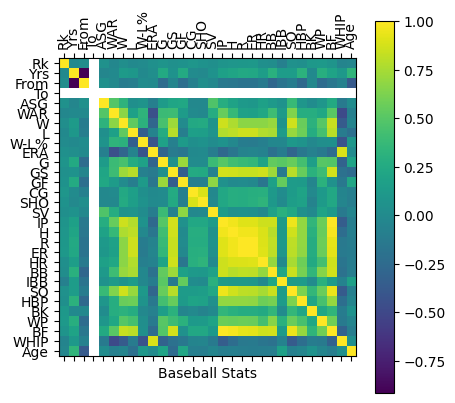

In [36]:
plt.matshow(base_data_corr)
plt.colorbar()
plt.xlabel("Baseball Stats")
plt.xticks(range(len(base_data_corr.index)), base_data_corr.index, rotation=90)
plt.yticks(range(len(base_data_corr.index)), base_data_corr.index)
# the lines of code will print a correlation matrix so that we can see in color what columns correlate best with others
# I believe it is easier to read than the correlation table

In [37]:
# I can tell from this correlation matrix that WAR, saves, and strike outs will correlate best with the All Star Games column

Text(0, 0.5, 'Percent Accuracy')

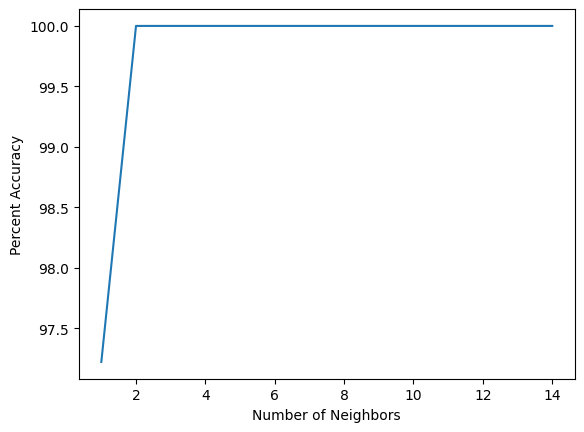

In [40]:
X = base[["WAR", "SV", "SO"]]
y = base["ASG"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

k_value = []
accuracies = []

for k in range(1, 15, 1):
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train, y_train)
    predictions = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    k_value.append(k)
    accuracies.append(accuracy*100)

plt.plot(k_value, accuracies)
plt.xlabel("Number of Neighbors")
plt.ylabel("Percent Accuracy")
# these lines of code will print a K-neighbors graph to show what number of neighbors will work best for finding the best accuracy for the 
# training algorithm

In [41]:
# I can tell from this table that the number of neighbors doesn't matter a whole lot for this test

97.22222222222221


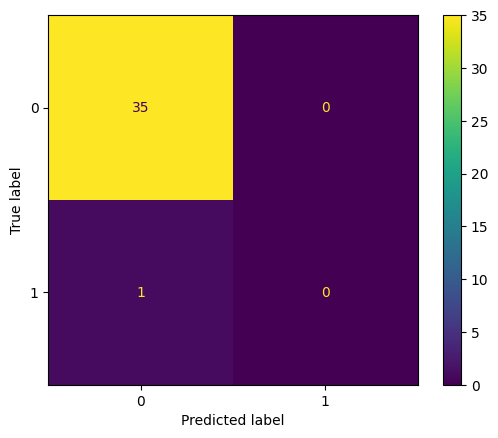

In [43]:
X = base[["WAR", "SV","SO"]]
y = base["ASG"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

classifier = KNeighborsClassifier(n_neighbors=3)

classifier.fit(X_train, y_train)

predictions = classifier.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(accuracy*100)
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)
# These lines of code will create a trained algorithm, idetify what the x and y component are, run a train split test, idetify the classifer
# and the number of neighbors, fit the classifier, set it to make predictions, print and calculate an accuracy score, and print a confusion 
# matrix to show the results it predicted

In [44]:
# When looking to imporve the accuracy of the training algorithm I use feature engineering and hyparameter tuning
# first I created a corelation matrix and found that WAR, SV, and SO where the most related to ASG so I used those as my x-components
# Then I tested to see what would be the best number of neighbors, after doing this I found that the number of neighbors didn't matter 
# so I kept that the same
# after changing the x-components I redid the training algorithm I got about 98% on my accuracy score, which was an increase from the first test
# The only prediction that it got wrong was that it did predict everyone wouldn't be an all star but one player was
# I would say that this is one of the easier stats to predict though based on the fact that these are all rookie pitchers and only a couple
# have been voted an all star so far
# I will also say that it could make a 100% prediction test but it would most likely be if none of the players that were all stars were
# in the percentage of data that was tested

In [1]:
import pandas as pd
from scipy.stats import chi2_contingency
# this will import the programs I need

In [2]:
base = pd.read_csv("Baseball_Data.csv")
# this will import the data I need

In [3]:
base = base.drop(275)
# this will drop the totals row

In [4]:
base = base.dropna()
# this will drop the null values

In [6]:
corr = scipy.stats.pearsonr(base["SO"], base["BB"])
print(corr)
print(corr [0])
correlation_coef = corr[0]
print("Correlation Coefficient:", correlation_coef)
# this will calculate and print the p-value for strikeouts and walks

NameError: name 'scipy' is not defined

In [43]:
# I can tell from this that wins do not have a relationship with strikeouts because the p-value of about 1.21 is greater than 0.05